In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from pymongo import MongoClient

In [8]:
client = MongoClient("mongodb://localhost:27017/")

db = client["ecommerce_db"]

print("Conexión exitosa a MongoDB")

Conexión exitosa a MongoDB


In [9]:
db.list_collection_names()

['sales', 'times', 'payments', 'items', 'stores', 'customers']

In [10]:
colecciones = [
    "customers",
    "items",
    "payments",
    "sales",
    "stores",
    "times"
]

for coleccion in colecciones:
    cantidad = db[coleccion].count_documents({})
    print(f"{coleccion}: {cantidad:,}")

customers: 9,191
items: 264
payments: 39
sales: 1,000,000
stores: 726
times: 99,999


In [11]:
db.sales.find_one()

{'_id': ObjectId('6a9f7cff4615a16e4df81230'),
 'payment_key': 'P026',
 'customer_key': 'C004510',
 'time_key': 'T049189',
 'item_key': 'I00177',
 'store_key': 'S00307',
 'quantity': 1,
 'unit': 'ct',
 'unit_price': 35.0,
 'total_price': 35.0}

In [12]:
pipeline_kpis = [
    {
        "$group": {
            "_id": None,
            "venta_total": {"$sum": "$total_price"},
            "numero_transacciones": {"$sum": 1},
            "clientes": {"$addToSet": "$customer_key"},
            "ticket_promedio": {"$avg": "$total_price"}
        }
    },
    {
        "$project": {
            "_id": 0,
            "venta_total": 1,
            "numero_transacciones": 1,
            "clientes_unicos": {"$size": "$clientes"},
            "ticket_promedio": 1
        }
    }
]

resultado_kpis = list(db.sales.aggregate(pipeline_kpis))

resultado_kpis

[{'venta_total': 105401435.75,
  'numero_transacciones': 1000000,
  'ticket_promedio': 105.40143575,
  'clientes_unicos': 9191}]

In [13]:
kpis = resultado_kpis[0]

print(f"Venta total: ${kpis['venta_total']:,.2f}")
print(f"Número de transacciones: {kpis['numero_transacciones']:,}")
print(f"Clientes únicos: {kpis['clientes_unicos']:,}")
print(f"Ticket promedio: ${kpis['ticket_promedio']:,.2f}")

Venta total: $105,401,435.75
Número de transacciones: 1,000,000
Clientes únicos: 9,191
Ticket promedio: $105.40


In [18]:
pipeline_evolucion = [
    {
        "$lookup": {
            "from": "times",
            "localField": "time_key",
            "foreignField": "time_key",
            "as": "time"
        }
    },
    {
        "$unwind": "$time"
    },
    {
        "$group": {
            "_id": {
                "year": "$time.year",
                "month": "$time.month"
            },
            "venta_total": {
                "$sum": "$total_price"
            },
            "transacciones": {
                "$sum": 1
            }
        }
    },
    {
        "$sort": {
            "_id.year": 1,
            "_id.month": 1
        }
    },
    {
        "$project": {
            "_id": 0,
            "year": "$_id.year",
            "month": "$_id.month",
            "venta_total": 1,
            "transacciones": 1
        }
    }
]

resultado_evolucion = list(
    db.sales.aggregate(
        pipeline_evolucion,
        allowDiskUse=True
    )
)

len(resultado_evolucion)

85

In [19]:
df_evolucion = pd.DataFrame(resultado_evolucion)

df_evolucion.head(10)

,venta_total,transacciones,year,month
0,496549.25,4686,2014,1
1,1122547.00,10713,2014,2
2,1262435.75,12019,2014,3
3,1245142.50,11750,2014,4
4,1268770.50,12085,2014,5
5,1240771.75,11793,2014,6
6,1317296.00,12491,2014,7
7,1293211.00,12369,2014,8
8,1279444.25,12191,2014,9
9,1299793.50,12298,2014,10


In [20]:
df_evolucion["periodo"] = pd.to_datetime(
    dict(
        year=df_evolucion["year"],
        month=df_evolucion["month"],
        day=1
    )
)

df_evolucion.head()

,venta_total,transacciones,year,month,periodo
0,496549.25,4686,2014,1,2014-01-01
1,1122547.00,10713,2014,2,2014-02-01
2,1262435.75,12019,2014,3,2014-03-01
3,1245142.50,11750,2014,4,2014-04-01
4,1268770.50,12085,2014,5,2014-05-01


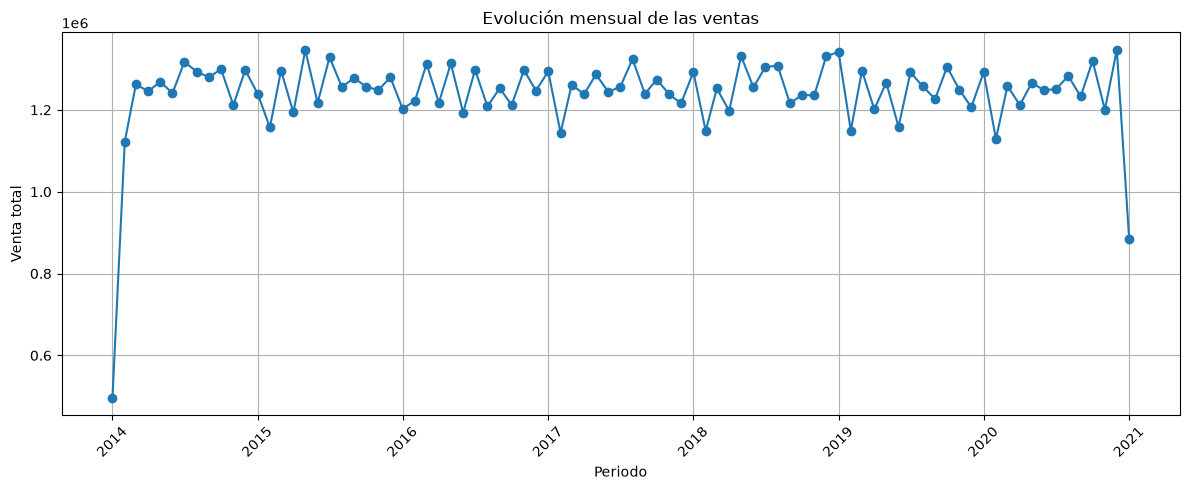

In [23]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_evolucion["periodo"],
    df_evolucion["venta_total"],
    marker="o"
)

plt.title("Evolución mensual de las ventas")
plt.xlabel("Periodo")
plt.ylabel("Venta total")
plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()

plt.show()

## Comparación de tiendas

Se analiza el desempeño de las tiendas según su venta total, número de transacciones y ticket promedio.

In [24]:
pipeline_tiendas = [
    {
        "$group": {
            "_id": "$store_key",
            "venta_total": {"$sum": "$total_price"},
            "transacciones": {"$sum": 1}
        }
    },
    {
        "$lookup": {
            "from": "stores",
            "localField": "_id",
            "foreignField": "store_key",
            "as": "store"
        }
    },
    {
        "$unwind": "$store"
    },
    {
        "$project": {
            "_id": 0,
            "store_key": "$_id",
            "division": "$store.division",
            "district": "$store.district",
            "upazila": "$store.upazila",
            "venta_total": 1,
            "transacciones": 1,
            "ticket_promedio": {
                "$divide": [
                    "$venta_total",
                    "$transacciones"
                ]
            }
        }
    },
    {
        "$sort": {
            "venta_total": -1
        }
    },
    {
        "$limit": 10
    }
]

resultado_tiendas = list(
    db.sales.aggregate(
        pipeline_tiendas,
        allowDiskUse=True
    )
)

resultado_tiendas

[{'venta_total': 159409.0,
  'transacciones': 1437,
  'store_key': 'S0010',
  'division': 'SYLHET',
  'district': 'MAULVIBAZAR',
  'upazila': 'JURI',
  'ticket_promedio': 110.93180236604036},
 {'venta_total': 158027.5,
  'transacciones': 1448,
  'store_key': 'S00601',
  'division': 'DHAKA',
  'district': 'DHAKA',
  'upazila': 'DARUS SALAM',
  'ticket_promedio': 109.1350138121547},
 {'venta_total': 157692.0,
  'transacciones': 1450,
  'store_key': 'S00328',
  'division': 'DHAKA',
  'district': 'MADARIPUR',
  'upazila': 'SHIBCHAR',
  'ticket_promedio': 108.75310344827587},
 {'venta_total': 157483.0,
  'transacciones': 1497,
  'store_key': 'S0039',
  'division': 'RANGPUR',
  'district': 'DINAJPUR',
  'upazila': 'BIRAMPUR',
  'ticket_promedio': 105.19906479625918},
 {'venta_total': 157377.5,
  'transacciones': 1465,
  'store_key': 'S0080',
  'division': 'RANGPUR',
  'district': 'PANCHAGARH',
  'upazila': 'BODA',
  'ticket_promedio': 107.42491467576792},
 {'venta_total': 157243.5,
  'transa

In [25]:
df_tiendas = pd.DataFrame(resultado_tiendas)

df_tiendas

,venta_total,transacciones,store_key,division,district,upazila,ticket_promedio
0,159409.00,1437,S0010,SYLHET,MAULVIBAZAR,JURI,110.931802
1,158027.50,1448,S00601,DHAKA,DHAKA,DARUS SALAM,109.135014
2,157692.00,1450,S00328,DHAKA,MADARIPUR,SHIBCHAR,108.753103
3,157483.00,1497,S0039,RANGPUR,DINAJPUR,BIRAMPUR,105.199065
4,157377.50,1465,S0080,RANGPUR,PANCHAGARH,BODA,107.424915
5,157243.50,1450,S00357,DHAKA,NARAYANGANJ,BANDAR,108.443793
6,156979.50,1467,S00411,CHITTAGONG,BRAHMANBARIA,AKHAURA,107.007157
7,156793.75,1464,S00708,CHITTAGONG,CHITTAGONG,PAHARTALI,107.099556
8,156767.75,1446,S00687,DHAKA,DHAKA,UTTARA PURBA,108.414765
9,156651.50,1407,S00266,DHAKA,DHAKA,PALLABI,111.337242


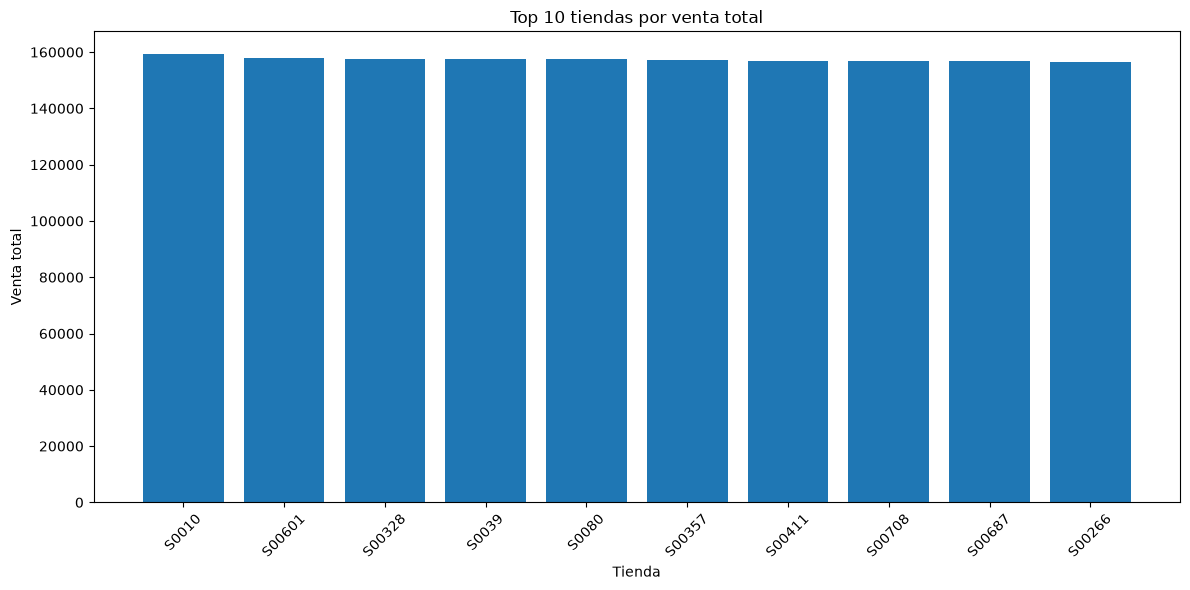

In [26]:
plt.figure(figsize=(12, 6))

plt.bar(
    df_tiendas["store_key"],
    df_tiendas["venta_total"]
)

plt.title("Top 10 tiendas por venta total")
plt.xlabel("Tienda")
plt.ylabel("Venta total")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Comparación de productos

Se identifican los productos con mayor venta total, considerando también las unidades vendidas y el número de transacciones.

In [27]:
pipeline_productos = [
    {
        "$group": {
            "_id": "$item_key",
            "venta_total": {"$sum": "$total_price"},
            "unidades_vendidas": {"$sum": "$quantity"},
            "transacciones": {"$sum": 1}
        }
    },
    {
        "$lookup": {
            "from": "items",
            "localField": "_id",
            "foreignField": "item_key",
            "as": "item"
        }
    },
    {
        "$unwind": "$item"
    },
    {
        "$project": {
            "_id": 0,
            "item_key": "$_id",
            "producto": "$item.item_name",
            "categoria": "$item.desc",
            "venta_total": 1,
            "unidades_vendidas": 1,
            "transacciones": 1
        }
    },
    {
        "$sort": {
            "venta_total": -1
        }
    },
    {
        "$limit": 10
    }
]

resultado_productos = list(
    db.sales.aggregate(
        pipeline_productos,
        allowDiskUse=True
    )
)

resultado_productos

[{'venta_total': 1305700.0,
  'unidades_vendidas': 23740,
  'transacciones': 3911,
  'item_key': 'I00061',
  'producto': 'Red Bull 12oz',
  'categoria': 'Beverage - Energy/Protein'},
 {'venta_total': 1245394.0,
  'unidades_vendidas': 23498,
  'transacciones': 3883,
  'item_key': 'I00115',
  'producto': 'K Cups Daily Chef Columbian Supremo',
  'categoria': 'Coffee K-Cups'},
 {'venta_total': 1188843.0,
  'unidades_vendidas': 22431,
  'transacciones': 3763,
  'item_key': 'I00119',
  'producto': 'K Cups Original Donut Shop Med. Roast',
  'categoria': 'Coffee K-Cups'},
 {'venta_total': 1109760.0,
  'unidades_vendidas': 23120,
  'transacciones': 3871,
  'item_key': 'I00116',
  'producto': 'K Cups Dunkin Donuts Medium Roast',
  'categoria': 'Coffee K-Cups'},
 {'venta_total': 1042406.0,
  'unidades_vendidas': 22661,
  'transacciones': 3812,
  'item_key': 'I00117',
  'producto': 'K Cups Folgers Lively Columbian',
  'categoria': 'Coffee K-Cups'},
 {'venta_total': 1012995.0,
  'unidades_vendidas'

In [32]:
df_productos = pd.DataFrame(resultado_productos)

df_productos

,venta_total,unidades_vendidas,transacciones,item_key,producto,categoria
0,1305700.0,23740,3911,I00061,Red Bull 12oz,Beverage - Energy/Protein
1,1245394.0,23498,3883,I00115,K Cups Daily Chef Columbian Supremo,Coffee K-Cups
2,1188843.0,22431,3763,I00119,K Cups Original Donut Shop Med. Roast,Coffee K-Cups
3,1109760.0,23120,3871,I00116,K Cups Dunkin Donuts Medium Roast,Coffee K-Cups
4,1042406.0,22661,3812,I00117,K Cups Folgers Lively Columbian,Coffee K-Cups
5,1012995.0,22511,3759,I00123,Honey Packets,Coffee Sweetener
6,995456.0,22624,3780,I00114,K Cups  Starbuck's Pike Place,Coffee K-Cups
7,957516.0,22798,3747,I00118,K Cups Organic Breakfast Blend,Coffee K-Cups
8,956886.0,22783,3815,I00113,K Cups - McCafe Premium Roast,Coffee K-Cups
9,933720.0,23343,3827,I00064,Red Bull Sugar Free 8.4 oz,Beverage - Energy/Protein


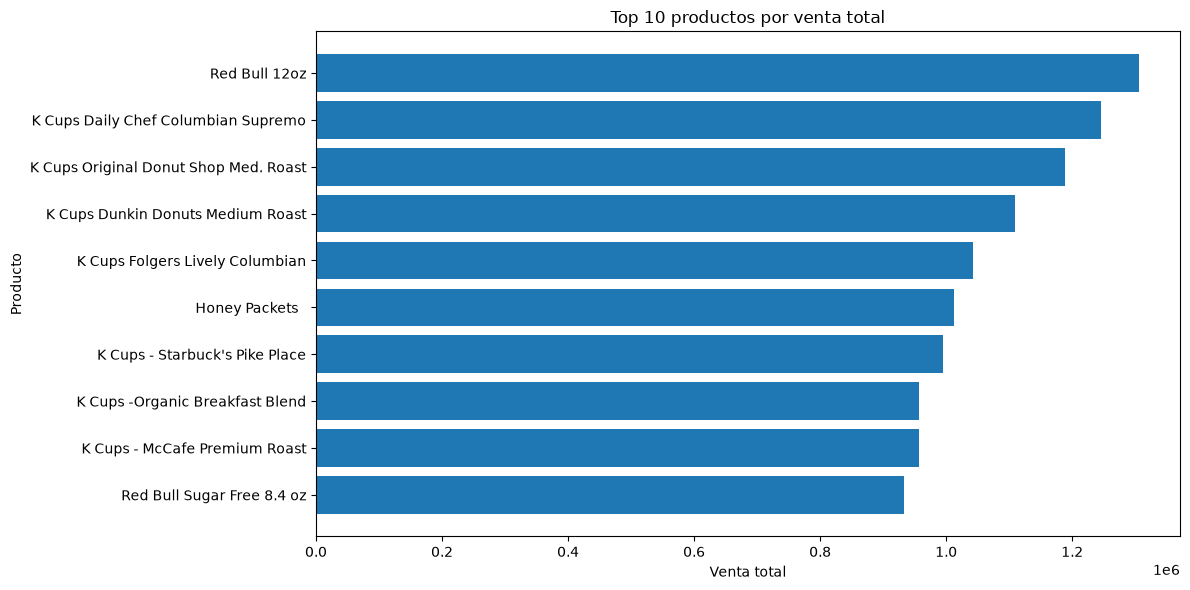

In [33]:
df_productos["producto"] = df_productos["producto"].str.replace(
    "\x96",
    "-",
    regex=False
)

plt.figure(figsize=(12, 6))

plt.barh(
    df_productos["producto"],
    df_productos["venta_total"]
)

plt.title("Top 10 productos por venta total")
plt.xlabel("Venta total")
plt.ylabel("Producto")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Análisis por método de pago

Se analiza la distribución de las ventas y transacciones según el método de pago utilizado.

In [34]:
pipeline_pagos = [
    {
        "$group": {
            "_id": "$payment_key",
            "venta_total": {"$sum": "$total_price"},
            "transacciones": {"$sum": 1}
        }
    },
    {
        "$lookup": {
            "from": "payments",
            "localField": "_id",
            "foreignField": "payment_key",
            "as": "payment"
        }
    },
    {
        "$unwind": "$payment"
    },
    {
        "$group": {
            "_id": "$payment.trans_type",
            "venta_total": {"$sum": "$venta_total"},
            "transacciones": {"$sum": "$transacciones"}
        }
    },
    {
        "$project": {
            "_id": 0,
            "metodo_pago": "$_id",
            "venta_total": 1,
            "transacciones": 1
        }
    },
    {
        "$sort": {
            "venta_total": -1
        }
    }
]

resultado_pagos = list(
    db.sales.aggregate(pipeline_pagos)
)

resultado_pagos

[{'venta_total': 94583038.5, 'transacciones': 897319, 'metodo_pago': 'card'},
 {'venta_total': 8109881.5, 'transacciones': 77091, 'metodo_pago': 'mobile'},
 {'venta_total': 2708515.75, 'transacciones': 25590, 'metodo_pago': 'cash'}]

In [35]:
df_pagos = pd.DataFrame(resultado_pagos)

df_pagos

,venta_total,transacciones,metodo_pago
0,94583038.50,897319,card
1,8109881.50,77091,mobile
2,2708515.75,25590,cash


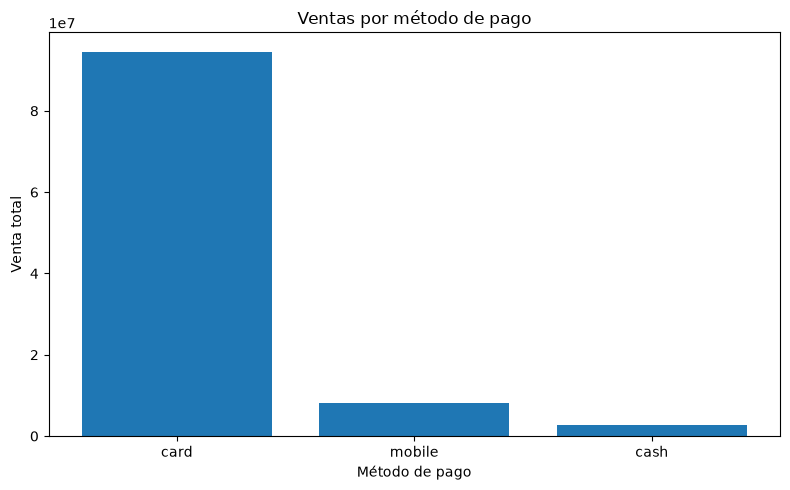

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    df_pagos["metodo_pago"],
    df_pagos["venta_total"]
)

plt.title("Ventas por método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Venta total")

plt.tight_layout()
plt.show()

## Validación de calidad de datos

Se revisan valores nulos, duplicados e integridad de claves entre la colección de ventas y las dimensiones relacionadas.

In [37]:
validaciones_nulos = {
    "customers_nombre_nulo": db.customers.count_documents({
        "$or": [
            {"name": None},
            {"name": {"$exists": False}}
        ]
    }),
    "items_unit_nulo": db.items.count_documents({
        "$or": [
            {"unit": None},
            {"unit": {"$exists": False}}
        ]
    }),
    "payments_bank_name_nulo": db.payments.count_documents({
        "$or": [
            {"bank_name": None},
            {"bank_name": {"$exists": False}}
        ]
    }),
    "sales_unit_nulo": db.sales.count_documents({
        "$or": [
            {"unit": None},
            {"unit": {"$exists": False}}
        ]
    })
}

validaciones_nulos

{'customers_nombre_nulo': 27,
 'items_unit_nulo': 1,
 'payments_bank_name_nulo': 1,
 'sales_unit_nulo': 3723}

In [38]:
pipeline_integridad = [
    {
        "$lookup": {
            "from": "customers",
            "localField": "customer_key",
            "foreignField": "customer_key",
            "as": "customer"
        }
    },
    {
        "$match": {
            "customer": {"$size": 0}
        }
    },
    {
        "$count": "ventas_sin_cliente"
    }
]

list(db.sales.aggregate(pipeline_integridad))

[]

In [39]:
relaciones = {
    "customer_key": "customers",
    "item_key": "items",
    "store_key": "stores",
    "time_key": "times",
    "payment_key": "payments"
}

for clave, coleccion in relaciones.items():

    pipeline = [
        {
            "$lookup": {
                "from": coleccion,
                "localField": clave,
                "foreignField": clave,
                "as": "relacion"
            }
        },
        {
            "$match": {
                "relacion": {"$size": 0}
            }
        },
        {
            "$count": "sin_coincidencia"
        }
    ]

    resultado = list(
        db.sales.aggregate(
            pipeline,
            allowDiskUse=True
        )
    )

    cantidad = (
        resultado[0]["sin_coincidencia"]
        if resultado
        else 0
    )

    print(f"{clave}: {cantidad} registros sin relación")

customer_key: 0 registros sin relación
item_key: 0 registros sin relación
store_key: 0 registros sin relación
time_key: 0 registros sin relación
payment_key: 0 registros sin relación


In [40]:
def buscar_claves_duplicadas(coleccion, campo):

    pipeline = [
        {
            "$group": {
                "_id": f"${campo}",
                "cantidad": {"$sum": 1}
            }
        },
        {
            "$match": {
                "cantidad": {"$gt": 1}
            }
        },
        {
            "$count": "duplicados"
        }
    ]

    resultado = list(
        db[coleccion].aggregate(pipeline)
    )

    return (
        resultado[0]["duplicados"]
        if resultado
        else 0
    )


print(
    "customers:",
    buscar_claves_duplicadas(
        "customers",
        "customer_key"
    )
)

print(
    "items:",
    buscar_claves_duplicadas(
        "items",
        "item_key"
    )
)

print(
    "stores:",
    buscar_claves_duplicadas(
        "stores",
        "store_key"
    )
)

print(
    "times:",
    buscar_claves_duplicadas(
        "times",
        "time_key"
    )
)

print(
    "payments:",
    buscar_claves_duplicadas(
        "payments",
        "payment_key"
    )
)

customers: 0
items: 0
stores: 0
times: 0
payments: 0


In [41]:
def buscar_claves_duplicadas(coleccion, campo):

    pipeline = [
        {
            "$group": {
                "_id": f"${campo}",
                "cantidad": {"$sum": 1}
            }
        },
        {
            "$match": {
                "cantidad": {"$gt": 1}
            }
        },
        {
            "$count": "duplicados"
        }
    ]

    resultado = list(
        db[coleccion].aggregate(pipeline)
    )

    return (
        resultado[0]["duplicados"]
        if resultado
        else 0
    )


print(
    "customers:",
    buscar_claves_duplicadas(
        "customers",
        "customer_key"
    )
)

print(
    "items:",
    buscar_claves_duplicadas(
        "items",
        "item_key"
    )
)

print(
    "stores:",
    buscar_claves_duplicadas(
        "stores",
        "store_key"
    )
)

print(
    "times:",
    buscar_claves_duplicadas(
        "times",
        "time_key"
    )
)

print(
    "payments:",
    buscar_claves_duplicadas(
        "payments",
        "payment_key"
    )
)

customers: 0
items: 0
stores: 0
times: 0
payments: 0


### Resultado de la validación

La carga a MongoDB mantiene la integridad referencial del dataset. No se encontraron claves huérfanas entre la colección `sales` y las colecciones `customers`, `items`, `stores`, `times` y `payments`.

Tampoco se detectaron claves identificadoras duplicadas en las colecciones dimensionales.

Se identificaron algunos valores nulos en determinados atributos. Estos valores no afectan las claves utilizadas para relacionar las colecciones, por lo que se conservaron para no modificar artificialmente la información original del dataset.

## Consumo de API pública

Se realiza una petición GET a la API pública DummyJSON para obtener información de productos y convertir parte de la respuesta JSON a un DataFrame de Pandas.

In [42]:
import requests

url = "https://dummyjson.com/products"

response = requests.get(
    url,
    params={
        "limit": 10,
        "select": "id,title,category,price,rating"
    }
)

print("Código de respuesta:", response.status_code)

Código de respuesta: 200


In [43]:
datos_api = response.json()

df_api = pd.DataFrame(datos_api["products"])

df_api

,id,title,category,price,rating
0,1,Essence Mascara Lash Princess,beauty,9.99,2.56
1,2,Eyeshadow Palette with Mirror,beauty,19.99,2.86
2,3,Powder Canister,beauty,14.99,4.64
3,4,Red Lipstick,beauty,12.99,4.36
4,5,Red Nail Polish,beauty,8.99,4.32
5,6,Calvin Klein CK One,fragrances,49.99,4.37
6,7,Chanel Coco Noir Eau De,fragrances,129.99,4.26
7,8,Dior J'adore,fragrances,89.99,3.80
8,9,Dolce Shine Eau de,fragrances,69.99,3.96
9,10,Gucci Bloom Eau de,fragrances,79.99,2.74


In [44]:
print(f"Productos obtenidos: {len(df_api)}")
print("\nColumnas:")
print(df_api.columns.tolist())

Productos obtenidos: 10

Columnas:
['id', 'title', 'category', 'price', 'rating']


### Resultado

La consulta a la API pública fue realizada correctamente mediante una petición HTTP GET. La respuesta en formato JSON fue procesada en Python y los registros de productos fueron convertidos a un DataFrame de Pandas.

Esta fuente externa se utiliza únicamente para demostrar el consumo de una API y no se integra con el dataset principal, de acuerdo con el alcance de la prueba.

## Diseño conceptual de API

A partir de los indicadores obtenidos, se proponen dos endpoints que podrían ser consumidos diariamente por un dashboard, ERP u otra aplicación.

### Endpoint 1: Resumen general de ventas

**Ruta**

`GET /api/v1/sales/summary`

**Parámetros**

- `start_date`: fecha inicial del análisis.
- `end_date`: fecha final del análisis.

Ejemplo:

`GET /api/v1/sales/summary?start_date=2020-01-01&end_date=2020-12-31`

**Información devuelta**

- Venta total.
- Número de transacciones.
- Clientes únicos.
- Ticket promedio.

**Procesamiento**

El endpoint ejecutaría un Aggregation Pipeline en MongoDB que filtre las ventas por el periodo solicitado y calcule los indicadores mediante `$match`, `$group` y `$project`.

**Ejemplo de respuesta JSON**

```json
{
  "start_date": "2020-01-01",
  "end_date": "2020-12-31",
  "venta_total": 15350000.50,
  "transacciones": 145620,
  "clientes_unicos": 8120,
  "ticket_promedio": 105.41
}

### Endpoint 2: Productos con mayores ventas

**Método y ruta**

`GET /api/v1/products/top`

**Parámetros**

- `limit`: número máximo de productos a devolver.
- `start_date`: fecha inicial del periodo.
- `end_date`: fecha final del periodo.

Ejemplo:

`GET /api/v1/products/top?limit=10&start_date=2020-01-01&end_date=2020-12-31`

**Información que devolvería**

- Código del producto.
- Nombre del producto.
- Venta total.
- Unidades vendidas.
- Número de transacciones.

**Procesamiento previo**

El endpoint ejecutaría un Aggregation Pipeline en MongoDB para:

1. Filtrar las ventas por fecha.
2. Agrupar las ventas por `item_key`.
3. Calcular venta total, unidades vendidas y transacciones.
4. Relacionar `sales` con `items` mediante `$lookup`.
5. Ordenar los productos por venta total.
6. Devolver únicamente los primeros productos indicados en `limit`.

**Ejemplo de respuesta JSON**

```json
{
  "productos": [
    {
      "item_key": "I001",
      "producto": "Red Bull 12oz",
      "venta_total": 1300000.50,
      "unidades_vendidas": 25200,
      "transacciones": 10500
    }
  ]
}

## Análisis final y conclusiones

### 6. ¿Cuáles son los tres hallazgos más importantes?

**1. Alta concentración de ventas mediante tarjeta.**  
El método de pago `card` concentra una proporción muy superior de las ventas frente a `mobile` y `cash`. Esto es relevante para la gerencia porque muestra una fuerte dependencia de los pagos con tarjeta y permite priorizar la disponibilidad y estabilidad de este canal de pago.

**2. Red Bull 12oz lidera las ventas por producto.**  
Dentro del ranking analizado, Red Bull 12oz presenta la mayor venta total. Esto puede ayudar a identificar productos estratégicos para inventario, promociones y abastecimiento.

**3. Las ventas presentan variaciones a través del tiempo.**  
La evolución mensual permite detectar periodos de mayor y menor actividad. Los valores extremos al inicio y final del periodo deben analizarse con cuidado, ya que podrían corresponder a meses incompletos y no necesariamente a cambios reales del comportamiento comercial.

### 7. ¿Qué indicador podría llevar a una conclusión equivocada si se observa solo?

La venta total puede ser engañosa si se analiza de forma aislada. Una tienda o producto puede presentar mayores ventas simplemente por tener más transacciones.

Por ello, contrastaría la venta total con el número de transacciones, unidades vendidas y ticket promedio.

### 8. ¿Qué investigaría con mayor profundidad?

Analizaría con mayor detalle el producto Red Bull 12oz debido a que presenta la mayor venta total del ranking.

Antes de recomendar una acción comercial, revisaría información adicional como margen de ganancia, costo, disponibilidad de inventario, frecuencia de reposición y comportamiento de ventas por tienda y periodo.

### 9. ¿Qué haría si dos áreas obtuvieran valores diferentes para Venta Total?

Primero validaría que ambas áreas estén utilizando el mismo periodo, filtros y definición de Venta Total.

Después revisaría:
- campos utilizados para el cálculo;
- registros duplicados;
- valores nulos;
- filtros aplicados;
- fechas consideradas;
- posibles diferencias en la actualización de los datos.

Finalmente compararía los resultados contra una consulta controlada directamente en MongoDB para establecer una única definición del indicador.

### 10. ¿Qué haría si este análisis se solicitara diariamente?

No mantendría el proceso únicamente como un notebook manual.

Propondría automatizar:
- la carga y validación de datos;
- las Aggregation Pipelines;
- el cálculo de indicadores;
- la actualización del dashboard;
- controles de calidad y alertas.

Solicitaría al equipo de Ingeniería endpoints o procesos programados que proporcionen indicadores ya procesados, evitando que cada aplicación consulte directamente todas las transacciones.

### 11. Uso de Inteligencia Artificial

Utilicé IA como apoyo para estructurar el proyecto, revisar código Python, proponer Aggregation Pipelines y organizar la documentación.

Verifiqué personalmente la conexión con MongoDB, la carga de las colecciones, los conteos de registros, las consultas ejecutadas, los resultados obtenidos y las visualizaciones.

No confiaría completamente a una IA decisiones relacionadas con la calidad de los datos, interpretación final del negocio o validación de indicadores sin comprobar previamente los resultados contra los datos originales.

## Decisiones de modelado y criterios técnicos

### 1. ¿Por qué elegí este modelo?

Se utilizó un modelo analítico similar a un esquema estrella, donde `sales` funciona como colección central de transacciones y las colecciones `customers`, `items`, `stores`, `times` y `payments` contienen la información descriptiva.

Esta estructura evita repetir información de clientes, productos, tiendas y medios de pago dentro de cada venta, facilita el mantenimiento de los datos y permite realizar relaciones mediante Aggregation Pipeline y `$lookup`.

### 2. ¿Qué información mantendría referenciada y qué podría estar embebida?

Mantendría referenciadas las entidades que pueden reutilizarse en muchas transacciones, como clientes, productos y tiendas.

En un escenario de optimización podría considerar embeber algunos atributos pequeños y poco cambiantes que se consulten constantemente, por ejemplo el año y mes de la transacción o el tipo de pago.

La decisión dependería de la frecuencia de consulta, volumen de información y necesidad de actualización de cada atributo.

### 3. ¿Qué revisaría primero si el volumen creciera a millones de registros?

Revisaría principalmente:

- Los índices utilizados por las consultas.
- Los campos realmente necesarios en cada consulta.
- El rendimiento de los Aggregation Pipelines mediante los planes de ejecución.
- La posibilidad de realizar agregaciones previas para indicadores consultados frecuentemente.
- El crecimiento de almacenamiento y memoria.
- Una estrategia de particionamiento o sharding si el volumen continuara aumentando.

También evitaría transferir grandes cantidades de documentos hacia Python cuando los cálculos puedan realizarse directamente en MongoDB.

### 4. ¿Qué cálculos se realizaron en MongoDB y cuáles en Python/Pandas?

Los cálculos principales, como Venta Total, número de transacciones, clientes únicos, ticket promedio, ventas por tienda, productos y métodos de pago, se realizaron mediante MongoDB Aggregation Pipeline.

Esto permite procesar los datos cerca de su origen y reducir la cantidad de información transferida.

Pandas se utilizó principalmente para organizar los resultados ya agregados, realizar transformaciones pequeñas y preparar los datos para las visualizaciones con Matplotlib.

### 5. ¿Qué cambiaría si existieran 20 millones de transacciones?

Con 20 millones de transacciones evitaría cargar los registros completos en memoria y mantendría la mayor parte del procesamiento dentro de MongoDB.

Implementaría índices adecuados para las claves y filtros más utilizados, consultaría únicamente los campos necesarios mediante proyecciones y revisaría los pipelines con herramientas de análisis de ejecución.

Para indicadores consultados diariamente consideraría colecciones agregadas o procesos batch que precalculen los resultados.

Si el crecimiento lo justificara, evaluaría sharding y estrategias adicionales de escalabilidad.